# Сравнение моделей (микро уровень)

Density, Time of Presence, Stop duration. Реальные треки vs симулированные (Unity CSV).

**Вход:** DXF с планом, папка CSV с реальными треками, папка Unity CSV с симуляцией.


In [1]:
import sys
from pathlib import Path

for d in [Path.cwd(), Path.cwd() / "model_search"]:
    if (d / "density.py").exists() and str(d) not in sys.path:
        sys.path.insert(0, str(d))
        break

PATH_DXF = str(Path("model_search") / "Floor_0.dxf") if (Path.cwd() / "model_search" / "Floor_0.dxf").exists() else "Floor_0.dxf"
PATH_TRAJECTORIES_CSV = "C://Users/malko/Desktop/Diploma/Term/bird-dataset-main/bird-dataset-main/data/normalized_trajectories"
CELL_SIZE_M = 1.0
PATH_SIMULATION_CSV = r"C:\Users\malko\Nancy_floor0\Assets\StreamingAssets\unity_tracks_bird"
PATH_UNITY_PLAN_DXF = r"C:\Users\malko\Nancy_floor0\Assets\StreamingAssets\unity_tracks.dxf"


In [2]:
%pip install -q ezdxf pandas matplotlib numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Микро уровень

Метрики движения в конкретных зонах: плотность, время присутствия, распределение длительностей остановок.

**В начале секции:** план + треки + сетка (реальные и симулированные).

### Density — карты плотности

Плотность посетителей на единицу площади. Сетка 1×1 м (параметр `CELL_SIZE_M`).

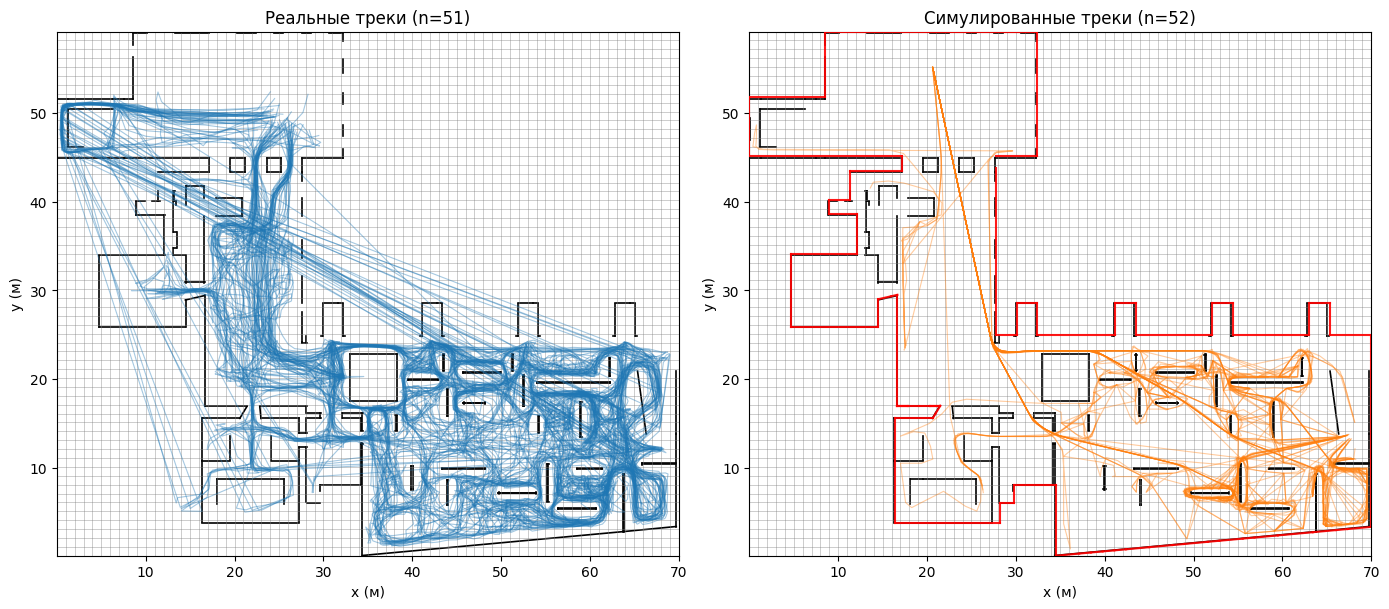

In [3]:
# Вводные картинки: план + треки + сетка (реальные и симулированные)
import matplotlib.pyplot as plt
import numpy as np

from density import load_floor0_trajectories, SCALE_FACTOR, compute_density_analysis
from plot_density_grids import load_floor_plan_segments, plot_plan_with_grid, plot_plan_with_grid_and_tracks

path_dxf = Path(PATH_DXF) if isinstance(PATH_DXF, str) else PATH_DXF
segments = load_floor_plan_segments(path_dxf, "Floor_plan")

# Сетка и BIRD-треки
d_real = compute_density_analysis(PATH_TRAJECTORIES_CSV, cell_size_m=CELL_SIZE_M)
xe, ye = d_real["x_edges"], d_real["y_edges"]
base = Path("model_search") if (Path.cwd() / "model_search").exists() else Path(".")
grid_json = base / "density_floor0.json"
if not grid_json.exists():
    import json
    json.dump({"x_edges_m": [round(float(x), 4) for x in xe], "y_edges_m": [round(float(y), 4) for y in ye]}, open(grid_json, "w", encoding="utf-8"), indent=2)
traj_bird, _, _, _ = load_floor0_trajectories(PATH_TRAJECTORIES_CSV)
# Разрыв треков при большом скачке по расстоянию или по времени (как в model_search_macro)
MAX_JUMP_M = 5.0
MAX_GAP_SEC = 300.0

def split_trajectory_by_gaps(df, scale_factor, max_jump_m, max_gap_sec):
    """Разбивает траекторию на сегменты при dist > max_jump_m (м) или time_diff > max_gap_sec (с)."""
    x_m = df["x"].astype(float).values * scale_factor
    y_m = df["y"].astype(float).values * scale_factor
    ts = df["timestamp"].astype(float).values
    if len(x_m) < 2:
        return [[(float(x_m[0]), float(y_m[0]))]] if len(x_m) == 1 else []
    dist = np.sqrt(np.diff(x_m) ** 2 + np.diff(y_m) ** 2)
    time_diff = np.diff(ts)
    breaks = np.where((dist > max_jump_m) | (time_diff > max_gap_sec))[0] + 1
    breaks = np.concatenate([[0], breaks, [len(x_m)]])
    segments = []
    for j in range(len(breaks) - 1):
        start, end = int(breaks[j]), int(breaks[j + 1])
        if end - start >= 2:
            segments.append([(float(x_m[k]), float(y_m[k])) for k in range(start, end)])
    return segments

traj_real_m = []
for df in traj_bird:
    traj_real_m.extend(split_trajectory_by_gaps(df, SCALE_FACTOR, MAX_JUMP_M, MAX_GAP_SEC))

# Unity-треки
traj_sim_m = None
path_sim = Path(PATH_SIMULATION_CSV)
path_unity_dxf = Path(PATH_UNITY_PLAN_DXF)
if grid_json.exists():
    try:
        from density_Unity import (
            load_trajectories, load_common_grid,
            compute_unity_to_bird_transform_from_floor_plan, compute_unity_to_bird_transform,
            load_unity_floor_plan_segments_in_bird_coords, _unity_to_bird
        )
        xe_u, ye_u = load_common_grid(str(grid_json))
        traj_sim_dfs, all_x, all_y, _ = load_trajectories(path_sim)
        sx, sy, ox, oy = compute_unity_to_bird_transform_from_floor_plan(xe_u, ye_u, str(path_unity_dxf.resolve()))
        traj_sim_m = []
        for df in traj_sim_dfs:
            xu = df["x"].astype(float).values
            yu = df["y"].astype(float).values
            xm, ym = _unity_to_bird(xu, yu, sx, sy, ox, oy)
            traj_sim_m.append([(float(x), float(y)) for x, y in zip(xm, ym)])
        segments_unity_red = load_unity_floor_plan_segments_in_bird_coords(
            str(path_unity_dxf), sx, sy, ox, oy, layers=["PLAN_FLOOR", "FLOOR"]
        )
    except Exception as e:
        print(f"[Симуляция] Не удалось загрузить треки: {e}")
        traj_sim_m = None
        segments_unity_red = []

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_plan_with_grid_and_tracks(axes[0], segments, xe, ye, traj_real_m, f"Реальные треки (n={len(traj_real_m)})", track_color="tab:blue")
if traj_sim_m is not None:
    plot_plan_with_grid_and_tracks(
        axes[1], segments, xe, ye, traj_sim_m,
        f"Симулированные треки (n={len(traj_sim_m)})",
        track_color="tab:orange",
        extra_segments=segments_unity_red,
        extra_segments_color="red",
    )
else:
    plot_plan_with_grid(xe, ye, segments, "Симулированные треки — нет данных", axes[1])
plt.tight_layout()
plt.show()

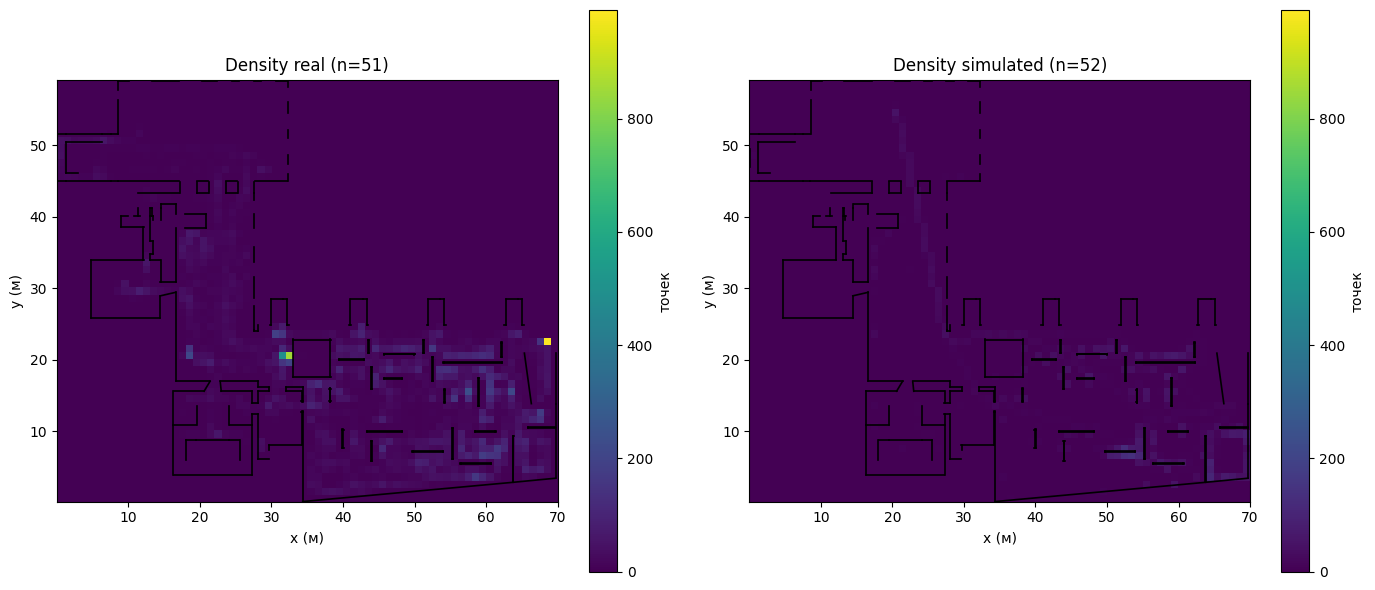

In [4]:
# Density: real и simulated
import json
import matplotlib.pyplot as plt
import numpy as np

# BIRD density
from density import compute_density_analysis as density_bird_analysis
d_real = density_bird_analysis(PATH_TRAJECTORIES_CSV, cell_size_m=CELL_SIZE_M)

# Сохраняем сетку для density_Unity (если density_floor0.json ещё не создан)
base = Path("model_search") if (Path.cwd() / "model_search").exists() else Path(".")
grid_json = base / "density_floor0.json"
if not grid_json.exists():
    json.dump(
        {"x_edges_m": [round(float(x), 4) for x in d_real["x_edges"]], "y_edges_m": [round(float(y), 4) for y in d_real["y_edges"]]},
        open(grid_json, "w", encoding="utf-8"),
        indent=2,
    )

# Unity density (на сетке BIRD)
from density_Unity import compute_density_analysis as density_unity_analysis
path_sim = Path(PATH_SIMULATION_CSV)
path_unity_dxf = Path(PATH_UNITY_PLAN_DXF)
try:
    d_sim = density_unity_analysis(
        str(path_sim.resolve()),
        grid_json_path=str(grid_json.resolve()),
        cell_size=CELL_SIZE_M,
        unity_plan_dxf_path=str(path_unity_dxf.resolve()),
    )
except FileNotFoundError:
    d_sim = None

# Загрузка плана для overlay
from plot_density_grids import load_floor_plan_segments, plot_heatmap_on_plan
path_dxf = Path(PATH_DXF) if isinstance(PATH_DXF, str) else PATH_DXF
segments = load_floor_plan_segments(path_dxf, "Floor_plan")
xe, ye = d_real["x_edges"], d_real["y_edges"]

# Единая шкала для сравнения real и simulated
hm_real, hm_sim = d_real["heatmap"], d_sim["heatmap"] if d_sim is not None else None
vmin_d, vmax_d = 0, max(hm_real.max(), hm_sim.max() if hm_sim is not None else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_heatmap_on_plan(axes[0], d_real["heatmap"], xe, ye, segments, f"Density real (n={d_real['n_trajectories']})", label="точек", vmin=vmin_d, vmax=vmax_d, draw_grid=False)
if d_sim is not None:
    plot_heatmap_on_plan(axes[1], d_sim["heatmap"], xe, ye, segments, f"Density simulated (n={d_sim['n_trajectories']})", label="точек", vmin=vmin_d, vmax=vmax_d, draw_grid=False)
else:
    axes[1].set_title("Density simulated — нет данных")
plt.tight_layout()
plt.show()

### Time of Presence (ToP)

Время присутствия = суммарное время (сек) в каждой ячейке по всем агентам.

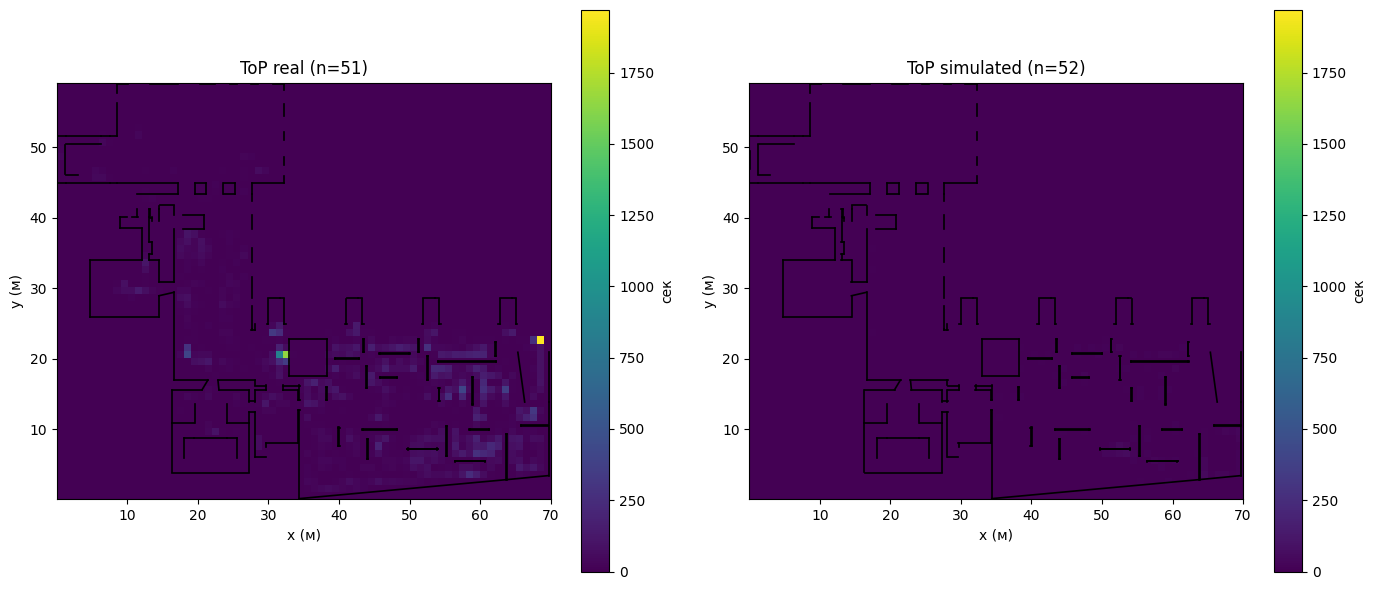

In [5]:
# Time of Presence: real и simulated — единая шкала
top_real, top_sim = d_real["top_matrix"], d_sim["top_matrix"] if d_sim is not None else None
vmin_t, vmax_t = 0, max(top_real.max(), top_sim.max() if top_sim is not None else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_heatmap_on_plan(axes[0], d_real["top_matrix"], xe, ye, segments, f"ToP real (n={d_real['n_trajectories']})", label="сек", vmin=vmin_t, vmax=vmax_t, draw_grid=False)
if d_sim is not None:
    plot_heatmap_on_plan(axes[1], d_sim["top_matrix"], xe, ye, segments, f"ToP simulated (n={d_sim['n_trajectories']})", label="сек", vmin=vmin_t, vmax=vmax_t, draw_grid=False)
else:
    axes[1].set_title("ToP simulated — нет данных")
plt.tight_layout()
plt.show()

### Stop duration distribution

Статистика длительностей остановок (run из 2+ точек в одной ячейке): mean, median, 75th/90th percentiles, proportion of long stops.

In [6]:
# Stop duration: real vs simulated
def print_stop_stats(name, stats):
    if not stats:
        print(f"{name}: нет остановок")
        return
    print(f"{name}:")
    print(f"  n_stops: {stats.get('n_stops', '—')}")
    print(f"  mean: {stats.get('mean_sec', '—')} сек, median: {stats.get('median_sec', '—')} сек")
    print(f"  75th: {stats.get('p75_sec', '—')} сек, 90th: {stats.get('p90_sec', '—')} сек")
    thr = stats.get("long_stop_threshold_sec", 30)
    prop = stats.get("proportion_long_stops", 0)
    print(f"  proportion of long stops (>{thr} сек): {prop:.2%}")

print_stop_stats("Real", d_real.get("stop_duration_stats"))
if d_sim is not None:
    print_stop_stats("Simulated", d_sim.get("stop_duration_stats"))

Real:
  n_stops: 4380
  mean: 8.93 сек, median: 4.0 сек
  75th: 10.0 сек, 90th: 18.0 сек
  proportion of long stops (>30.0 сек): 4.61%
Simulated:
  n_stops: 738
  mean: 2.59 сек, median: 2.51 сек
  75th: 3.89 сек, 90th: 4.52 сек
  proportion of long stops (>30.0 сек): 0.00%
